# 12. ベイズ最適化と Thompson サンプリング — 不確実性を使って賢く探索する

## この章で分かること

- **探索と活用 (explore vs exploit)** のジレンマ
- **Thompson サンプリング**: 事後から 1 つ引いて、それに対して貪欲に動く
- **多腕バンディット** と A/B テストの逐次版(03 章の続き)
- **ベイズ最適化**: ガウス過程 (GP) を代理モデルに、高価な関数を少ない試行で最適化
- 応用: ハイパーパラメータ探索

ここまでは「データを観測して事後を更新する」受け身の推論でした。
本章は **事後分布を使って次に何を試すかを決める** — 能動的な意思決定です。

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from bayes_textbook import visualization as viz
from bayes_textbook.models import (
    GaussianProcess, epsilon_greedy_bandit, expected_improvement, thompson_bandit,
)

rng = np.random.default_rng(42)
np.set_printoptions(precision=4, suppress=True)

## 1. 探索 vs 活用 — バンディット問題

スロットマシン(腕)が $K$ 台。各腕の当たり確率 $\theta_k$ は未知。
限られた試行で報酬を最大化したい。ここに緊張があります。

- **活用 (exploit)**: 今いちばん良さそうな腕を引く(が、推定が間違っていたら損)
- **探索 (explore)**: 自信のない腕も試す(が、外れ腕に試行を浪費するかも)

A/B テスト(03 章)は「全訪問者を均等に割る」純粋な探索でした。
バンディットは **探索しながら同時に活用** して、テスト期間中の損失(リグレット)も小さくします。

## 2. Thompson サンプリング — 事後に賭ける

驚くほど単純で強力な戦略:

1. 各腕の当たり率の **事後分布**($\mathrm{Beta}$、03 章)から $\tilde\theta_k$ を **1 つサンプリング**
2. $\tilde\theta_k$ が最大の腕を引く
3. 結果で事後を更新

「自信のある腕はサンプルがほぼ確定値 → よく選ばれる(活用)。
自信のない腕はサンプルがばらつく → ときどき高い値が出て選ばれる(探索)」。
**探索と活用が事後分布から自動的に湧き出る** のがこの手法の美しさです。

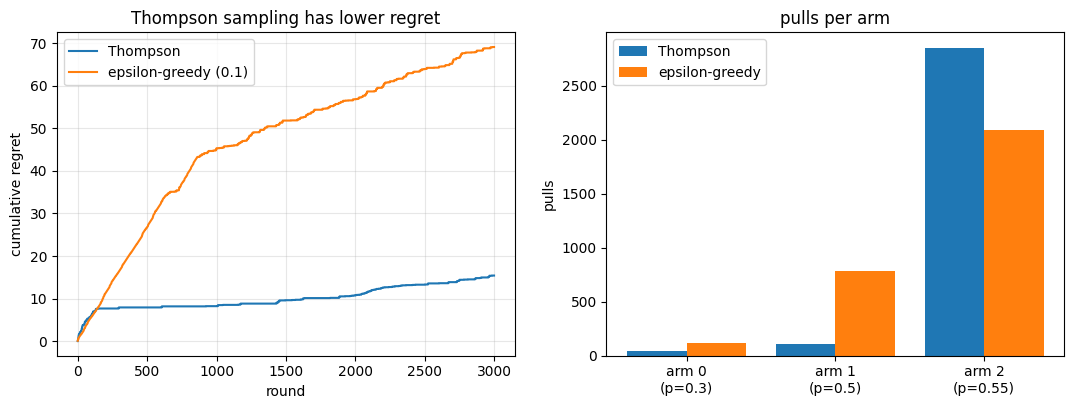

final regret: Thompson=15.4, epsilon-greedy=69.1


In [2]:
# Thompson sampling vs epsilon-greedy on a 3-armed Bernoulli bandit.
true_rates = [0.30, 0.50, 0.55]      # arm 2 is best, but 1 and 2 are close
pulls_ts, regret_ts = thompson_bandit(true_rates, n_rounds=3000, seed=0)
pulls_eps, regret_eps = epsilon_greedy_bandit(true_rates, n_rounds=3000, epsilon=0.1, seed=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].plot(regret_ts, label="Thompson")
axes[0].plot(regret_eps, label="epsilon-greedy (0.1)")
axes[0].set_xlabel("round"); axes[0].set_ylabel("cumulative regret")
axes[0].set_title("Thompson sampling has lower regret"); axes[0].grid(alpha=0.3); axes[0].legend()
x = np.arange(3)
axes[1].bar(x - 0.2, pulls_ts, 0.4, label="Thompson")
axes[1].bar(x + 0.2, pulls_eps, 0.4, label="epsilon-greedy")
axes[1].set_xticks(x, [f"arm {i}\n(p={true_rates[i]})" for i in range(3)])
axes[1].set_ylabel("pulls"); axes[1].set_title("pulls per arm"); axes[1].legend()
plt.show()
print(f"final regret: Thompson={regret_ts[-1]:.1f}, epsilon-greedy={regret_eps[-1]:.1f}")

Thompson は最良腕(arm 2)に試行を集中させつつ、僅差の arm 1 も十分試して取り違えを防ぎ、
累積リグレットを小さく抑えます。$\epsilon$-greedy は固定割合で無駄な探索を続けるため損が積もります。

## 3. A/B テストをバンディットとして回す

03 章の A/B テストは「期間を決めて均等割り → 最後に判定」でした。
バンディット化すると、**良い方に自動的にトラフィックを寄せながら** 学習でき、
テスト中の機会損失が減ります。逐次更新の様子を可視化します。

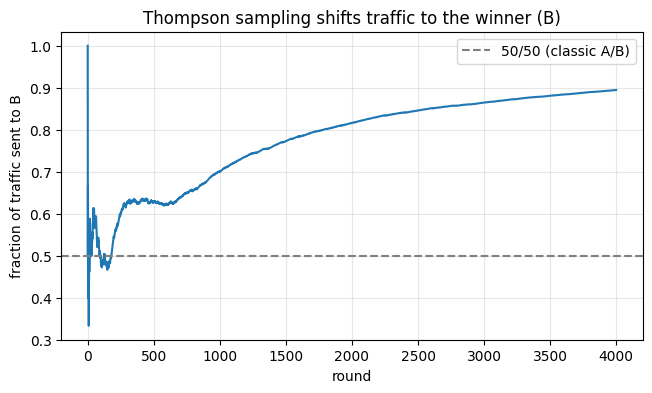

final traffic share to B = 89.5%  (B is the better arm)


In [3]:
# Watch Thompson sampling steer traffic toward the better variant over time.
rates = [0.05, 0.065]                 # A vs B conversion rates
rng2 = np.random.default_rng(1)
alpha = np.ones(2); beta = np.ones(2)
share_b = []
for t in range(4000):
    s = rng2.beta(alpha, beta)
    arm = int(np.argmax(s))
    reward = rng2.random() < rates[arm]
    alpha[arm] += reward; beta[arm] += 1 - reward
    share_b.append(alpha[1] + beta[1] - 2)        # cumulative pulls of B
share_b = np.array(share_b) / (np.arange(1, 4001))
plt.figure(figsize=(7.5, 4))
plt.plot(share_b)
plt.axhline(0.5, color="gray", ls="--", label="50/50 (classic A/B)")
plt.xlabel("round"); plt.ylabel("fraction of traffic sent to B")
plt.title("Thompson sampling shifts traffic to the winner (B)"); plt.grid(alpha=0.3); plt.legend()
plt.show()
print(f"final traffic share to B = {share_b[-1]:.1%}  (B is the better arm)")

## 4. ベイズ最適化 — 高価な関数を少ない試行で

ハイパーパラメータ探索のように、**1 回の評価が高価**(モデルを再学習するなど)な
ブラックボックス関数 $f(x)$ を最小化したい。総当たりは高すぎる。

**ベイズ最適化** の発想:

1. これまでの評価点に **ガウス過程 (GP)** を当てはめ、$f$ の事後(平均 ± 不確実性)を作る
2. **獲得関数**(次にどこを試すと得か)が最大の点を次に評価する
3. 繰り返す

GP は 04 章の「正規 × 正規 → 正規」を **関数** に持ち上げたもの。
まず GP が少数の点から関数を推定し、未観測領域で不確実性が膨らむ様子を見ます。

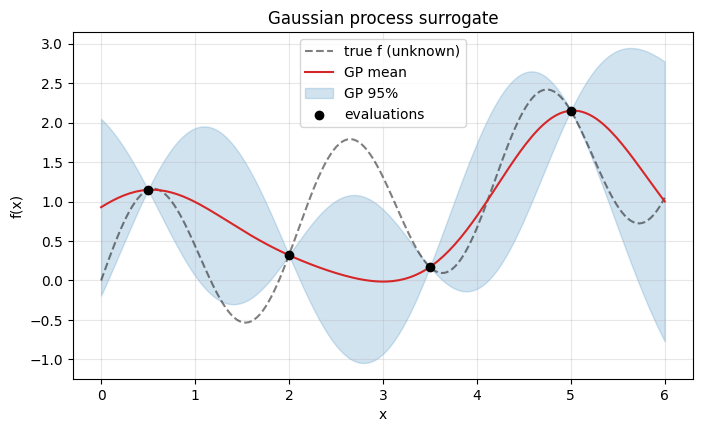

In [4]:
# A GP surrogate: confident near data, uncertain in the gaps.
def f(x):
    return np.sin(3 * x) + 0.3 * x        # the (pretended-expensive) black box

X_obs = np.array([0.5, 2.0, 3.5, 5.0])
y_obs = f(X_obs)
gp = GaussianProcess(length_scale=0.8, signal_var=1.0, noise=1e-6).fit(X_obs[:, None], y_obs)

grid = np.linspace(0, 6, 200)
mean, sd = gp.predict(grid[:, None])
plt.figure(figsize=(8, 4.5))
plt.plot(grid, f(grid), "k--", alpha=0.5, label="true f (unknown)")
plt.plot(grid, mean, "#d62728", label="GP mean")
plt.fill_between(grid, mean - 2 * sd, mean + 2 * sd, alpha=0.2, color="#1f77b4", label="GP 95%")
plt.scatter(X_obs, y_obs, color="k", zorder=3, label="evaluations")
plt.legend(); plt.grid(alpha=0.3); plt.xlabel("x"); plt.ylabel("f(x)")
plt.title("Gaussian process surrogate")
plt.show()

## 5. 獲得関数で次の点を選ぶ — 最適化ループ

**期待改善 (Expected Improvement, EI)**: 現在のベスト値をどれだけ更新できそうかの期待値。
「平均が低い(良い)場所」と「不確実性が高い(まだ調べていない)場所」の両方を高く評価し、
**活用と探索を一つの式で両立** します。GP の不確実性があるからこそ書ける獲得関数です。

after 8 evaluations: best x = 1.525, f = -0.533
true minimum near x = 1.545, f = -0.533


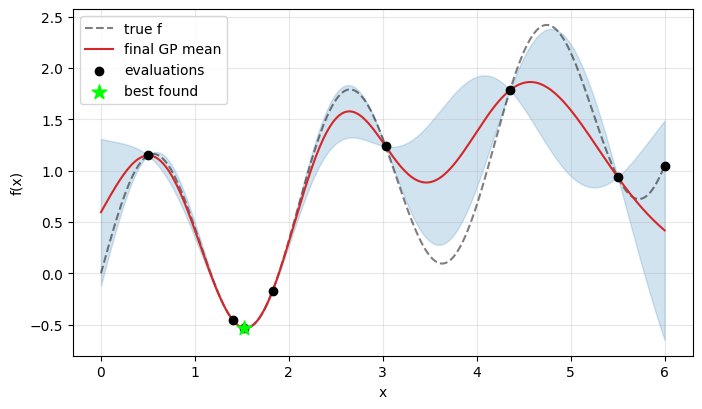

In [5]:
# Bayesian optimization loop: EI picks the next point; the minimum is found fast.
X_eval = [0.5, 5.5]
y_eval = [f(x) for x in X_eval]
grid = np.linspace(0, 6, 300)
for step in range(6):
    gp = GaussianProcess(length_scale=0.8, noise=1e-6).fit(np.array(X_eval)[:, None], y_eval)
    ei = expected_improvement(gp, grid[:, None], best_y=min(y_eval))
    x_next = grid[int(np.argmax(ei))]
    X_eval.append(float(x_next)); y_eval.append(float(f(x_next)))

best_i = int(np.argmin(y_eval))
true_x = grid[np.argmin(f(grid))]
print(f"after {len(X_eval)} evaluations: best x = {X_eval[best_i]:.3f}, f = {y_eval[best_i]:.3f}")
print(f"true minimum near x = {true_x:.3f}, f = {f(true_x):.3f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(grid, f(grid), "k--", alpha=0.5, label="true f")
mean, sd = gp.predict(grid[:, None])
ax.plot(grid, mean, "#d62728", label="final GP mean")
ax.fill_between(grid, mean - 2 * sd, mean + 2 * sd, alpha=0.2, color="#1f77b4")
ax.scatter(X_eval, y_eval, color="k", zorder=3, label="evaluations")
ax.scatter([X_eval[best_i]], [y_eval[best_i]], color="lime", s=120, marker="*", zorder=4, label="best found")
ax.legend(); ax.grid(alpha=0.3); ax.set_xlabel("x"); ax.set_ylabel("f(x)")
plt.show()

6 回の評価でほぼ最小に到達。総当たり(数百点)より桁違いに効率的です。
**不確実性の高い所を優先的に潰す** ことで、賢く探索しています。

## 6. Failure Mode

- **GP のカーネル長さスケール**の誤設定: 長すぎると関数を平坦と誤認、短すぎると過敏に。
  実務では周辺尤度最大化でカーネルを学習する(本章は固定)。
- **獲得関数の局所最適**: EI 自体の最大化も多峰。グリッド/多点再スタートで対処。
- **次元の呪い**: GP ベイズ最適化は低〜中次元(〜20 程度)向き。高次元では工夫が要る。
- **Thompson の事前依存**: バンディットの事前が極端だと初期の探索が偏る。

## 7. まとめ

- 探索と活用のジレンマは、**事後分布を使う** と自然に解ける。
- **Thompson サンプリング**: 事後から引いて貪欲に動くだけ。A/B テストの逐次版として強力(低リグレット)。
- **ベイズ最適化**: GP 代理モデル + 獲得関数(EI)で、高価な関数を少ない試行で最適化。
- 鍵はどちらも **不確実性の定量化** — ベイズが意思決定に直結する好例。
- 関連: `gto`(相手レンジの逐次推定)・`autostock`(戦略探索)・ML のハイパラ調整。

## 8. Exercises

1. Thompson サンプリングの腕数を 5 に増やし、リグレットの増え方を観察せよ。
2. $\epsilon$-greedy の $\epsilon$ を 0.01 / 0.1 / 0.3 と変え、リグレットとの関係を調べよ。
3. §4 の GP の `length_scale` を 0.3 / 0.8 / 3.0 と変え、事後の形がどう変わるか見よ。
4. ベイズ最適化の初期点を 1 点だけにして、最小到達までの評価回数がどう変わるか調べよ。
5. 獲得関数を EI から **UCB**(`mean - kappa * sd` を最小化)に変えて挙動を比較せよ。
6. (発展)2 次元の関数 $f(x, y)$ に GP ベイズ最適化を拡張せよ(`GaussianProcess` は多次元入力対応)。

## ガウス過程回帰:データ付近で帯が縮む(インタラクティブ)

GP 事後の平均と $\pm 2\sigma$ 帯。観測点を増やすスライダーを動かすと、点の近くで不確実性が締まり、データのない領域では広いまま残る。

In [6]:
import plotly.io as pio
from bayes_textbook import visualization as viz

pio.renderers.default = "plotly_mimetype+notebook_connected"
fig = viz.plotly_gp_regression()
fig.show()

## 累積リグレット:Thompson vs ε-greedy(インタラクティブ)

Thompson サンプリングは事後分布から賢く探索するため、ε-greedy より累積後悔(リグレット)を低く抑えられる。

In [7]:
import plotly.io as pio
from bayes_textbook import visualization as viz

pio.renderers.default = "plotly_mimetype+notebook_connected"
fig = viz.plotly_bandit_regret()
fig.show()